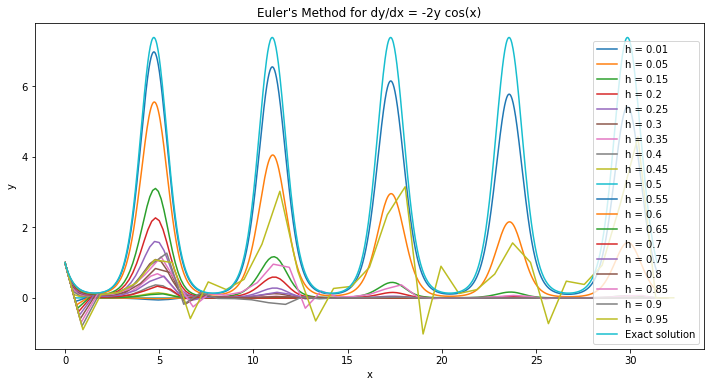

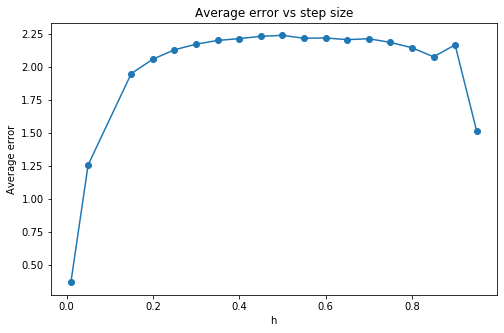

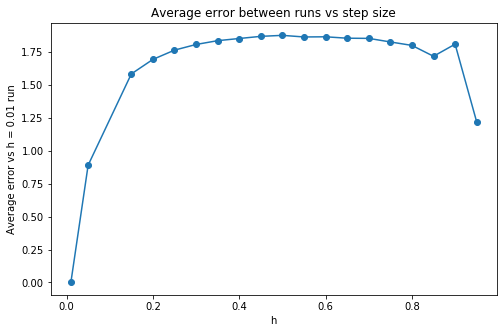

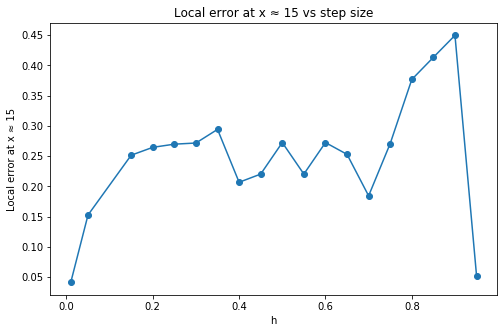

Comparison when x ≈ 15
h = 0.01, x = 15.0000, Euler y = 0.231440, Exact y = 0.272375, Local error = 0.040935
h = 0.05, x = 15.0000, Euler y = 0.119869, Exact y = 0.272375, Local error = 0.152506
h = 0.15, x = 15.0000, Euler y = 0.020921, Exact y = 0.272375, Local error = 0.251454
h = 0.20, x = 15.0000, Euler y = 0.007903, Exact y = 0.272375, Local error = 0.264472
h = 0.25, x = 15.0000, Euler y = 0.002662, Exact y = 0.272375, Local error = 0.269713
h = 0.30, x = 15.0000, Euler y = 0.000753, Exact y = 0.272375, Local error = 0.271622
h = 0.35, x = 15.0500, Euler y = 0.000170, Exact y = 0.294342, Local error = 0.294172
h = 0.40, x = 14.8000, Euler y = 0.000018, Exact y = 0.206696, Local error = 0.206679
h = 0.45, x = 14.8500, Euler y = 0.000001, Exact y = 0.220243, Local error = 0.220242
h = 0.50, x = 15.0000, Euler y = 0.000000, Exact y = 0.272375, Local error = 0.272375
h = 0.55, x = 14.8500, Euler y = 0.000000, Exact y = 0.220243, Local error = 0.220243
h = 0.60, x = 15.0000, Euler y 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,y):
    return -2 * y * np.cos(x)

def y_exact(x):
    return np.exp(-2 * np.sin(x))

def euler(h):
    x0 = 0
    xf = 10*np.pi
    y0 = 1.0
    
    x_values = np.arange(x0, xf + h, h)
    y_values = np.zeros(len(x_values))
    
    y_values[0] = y0
    
    for i in range(1, len(x_values)):
        xn = x_values[i-1]
        yn = y_values[i-1]
        y_values[i] = yn + h * f(xn,yn)
        
    return x_values, y_values

h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

avg_y_values = []
avg_errors = []
local_errors = []
x_15_values = []
y_15_values = []
exact_15_values = []
avg_run_errors = []
x_ref, y_ref = euler(0.01)

plt.figure(figsize=(12, 6))

for h in h_values:
    x,y = euler(h)
    y_true = y_exact(x)
    error = np.abs(y - y_true)
    
    avg_y_values.append(np.mean(y))
    avg_errors.append(np.mean(error))
    index_15 = np.argmin(np.abs(x - 15))
    local_errors.append(np.abs(y[index_15] - y_true[index_15]))
    x_15_values.append(x[index_15])
    y_15_values.append(y[index_15])
    exact_15_values.append(y_true[index_15])
    
    y_ref_on_x = np.interp(x, x_ref, y_ref) 
    run_error = np.abs(y - y_ref_on_x)
    avg_run_errors.append(np.mean(run_error))
    
    plt.plot(x,y,label = f'h = {h}')
    
x_exact = np.linspace(0, 10*np.pi, 1000)
plt.plot(x_exact, y_exact(x_exact), label='Exact solution')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method for dy/dx = -2y cos(x)")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(h_values, avg_errors, marker='o')
plt.xlabel("h")
plt.ylabel("Average error")
plt.title("Average error vs step size")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(h_values, avg_run_errors, marker='o')
plt.xlabel("h")
plt.ylabel("Average error vs h = 0.01 run")
plt.title("Average error between runs vs step size")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(h_values, local_errors, marker='o')
plt.xlabel("h")
plt.ylabel("Local error at x ≈ 15")
plt.title("Local error at x ≈ 15 vs step size")
plt.show()

print("Comparison when x ≈ 15")
for i in range(len(h_values)):
    print(f"h = {h_values[i]:.2f}, x = {x_15_values[i]:.4f}, Euler y = {y_15_values[i]:.6f}, Exact y = {exact_15_values[i]:.6f}, Local error = {local_errors[i]:.6f}")

As the h-value is getting smaller, Euler's method is producing a solution much closer to the exact solution. In contrast, the larger h-values appear to be increasingly inaccurate, producing misshapen curves. This is happening due to the fact that Euler's method is done using a linear approximation, and bigger steps allow the error to build up over intervals.
Average error, average error between runs, and the local error near x≈15 appear to be generally increasing as the step size increases. These graphs also affirm the fact that bigger step sizes result in higher error. The comparison between runs also reflected this trend where larger h-values tend to become increasingly inaccurate and diverge from the more accurate, smaller step sizes.

# Stability Analysis Addendum
For the equation: dy/dx = -2y cos(x), we are able to apply stability analysis using the linear test equation and the stability condition. However, the coefficient is not constant in this case because of cos(x). To deal with this, we have to apply stability analysis at each step.
With f(x,y)=−2y, λ was -2. However, our equation results in λ(x) = -2cos(x). 
To find the stability condition, we substitute f(x,y)=λy into Euler's formula. Using ∣1+hλ∣≤1 from the notes, we end up with ∣1−2hcos(x_n)∣≤1. From the case of cos(x)=1, we end up with a bounding condition of h≤1.